# 03 — KPI Analysis & Export
**Project:** KPI Operations Pipeline · **Stage 3 of 3**

Aqui calculamos os KPIs finais, geramos os gráficos e exportamos o arquivo que o Power BI vai consumir.  
É aqui que os dados viram **insights de negócio**.


## 1. Imports e carregamento do dataset limpo

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

%matplotlib inline
sns.set_style("whitegrid")
sns.set_palette("muted")

PROJECT_ROOT = Path.cwd().parent
CLEAN_PATH   = PROJECT_ROOT / "data" / "processed" / "tickets_clean.csv"
KPI_PATH     = PROJECT_ROOT / "data" / "processed" / "kpi_processed.csv"
CHARTS_PATH  = PROJECT_ROOT / "docs" / "screenshots"
CHARTS_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CLEAN_PATH)
if "sla_met" in df.columns:
    df["sla_met"] = df["sla_met"].astype(bool)

print(f"Carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Carregado: 8,469 linhas × 20 colunas


## 2. Identificar a dimensão de análise

In [10]:
# Vamos agregar os KPIs por produto, canal ou tipo de ticket
CANDIDATES = ["product_purchased", "ticket_type", "ticket_channel", "ticket_subject"]
GROUP_COL  = next((c for c in CANDIDATES if c in df.columns), None)
CSAT_COL   = next((c for c in df.columns if "satisfaction" in c or "csat" in c or "rating" in c), None)

if GROUP_COL is None:
    raise ValueError(f"Nenhuma coluna de agrupamento encontrada. Disponíveis: {df.columns.tolist()}")

print(f"Agrupando por : '{GROUP_COL}'")
print(f"CSAT           : '{CSAT_COL}'")
print(f"Grupos únicos  : {df[GROUP_COL].nunique()}")
print(f"Valores        : {df[GROUP_COL].unique().tolist()}")

Agrupando por : 'product_purchased'
CSAT           : 'customer_satisfaction_rating'
Grupos únicos  : 0
Valores        : [nan]


## 3. Calcular tabela de KPIs

In [11]:
# Agregação com named aggregations: mais legível que .agg({})
# Cada chave = nome da nova coluna
# Cada valor = (coluna_fonte, função_de_agregação)

agg_spec = {
    "ticket_volume":  ("resolution_hours", "count"),   # volume = contagem
    "mttr_hours":     ("resolution_hours", "mean"),    # MTTR = média do tempo
    "sla_compliance": ("sla_met",          "mean"),    # proporção de True
}
if CSAT_COL:
    agg_spec["avg_csat"] = (CSAT_COL, "mean")

kpi = (df.groupby(GROUP_COL)
         .agg(**agg_spec)
         .reset_index()
         .rename(columns={GROUP_COL: "dimension"}))

# Formatar para leitura
kpi["mttr_hours"]     = kpi["mttr_hours"].round(1)
kpi["sla_compliance"] = (kpi["sla_compliance"] * 100).round(1)  # proporção → percentual
if CSAT_COL:
    kpi["avg_csat"] = kpi["avg_csat"].round(2)

kpi["pipeline_run_at"] = datetime.now().strftime("%Y-%m-%d %H:%M")

print(f"KPI table ({len(kpi)} grupos):")
print(kpi.drop(columns=["pipeline_run_at"]).to_string(index=False))

KPI table (0 grupos):
Empty DataFrame
Columns: [dimension, ticket_volume, mttr_hours, sla_compliance, avg_csat]
Index: []


## 4. Gráfico A — MTTR por dimensão

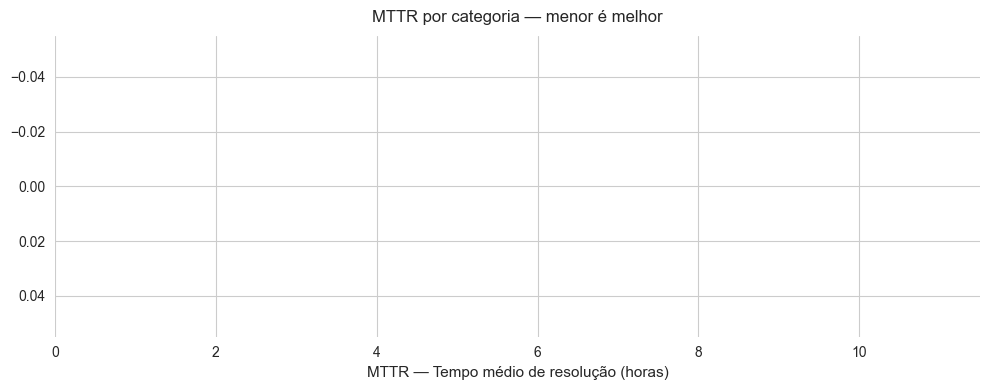

Gráfico salvo: c:\Users\arthu\%USERPROFILE%\Documents\GitHub\kpi-operations-pipeline\docs\screenshots\kpi_mttr.png


In [12]:
# MTTR: quanto menor, melhor
# Recrutadores de CS/ops reconhecem esse gráfico imediatamente

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MTTR: quanto menor, melhor
# Recrutadores de CS/ops reconhecem esse gráfico imediatamente

# --- CORREÇÃO AQUI: Forçamos a coluna a ser numérica antes de ordenar e desenhar ---
kpi["mttr_hours"] = pd.to_numeric(kpi["mttr_hours"], errors="coerce")

# Ordenamos os dados (linhas vazias/NaN vão automaticamente para o final)
plot_df = kpi.sort_values("mttr_hours", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.55)))
bars = ax.barh(plot_df["dimension"], plot_df["mttr_hours"],
               color="#4C72B0", edgecolor="white", height=0.6)

# Adicionamos os textos das barras apenas se o valor for um número válido
for bar, val in zip(bars, plot_df["mttr_hours"]):
    if pd.notna(val):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}h", va="center", ha="left", fontsize=9)

ax.set_xlabel("MTTR — Tempo médio de resolução (horas)", fontsize=11)
ax.set_title("MTTR por categoria — menor é melhor", fontsize=12, pad=10)

# --- CORREÇÃO AQUI: Calculamos o valor máximo ignorando NaNs com segurança ---
max_val = np.nanmax(plot_df["mttr_hours"]) if plot_df["mttr_hours"].notna().any() else 0

# Se o máximo for 0 ou inválido, usamos 10 como padrão para o gráfico não quebrar
if max_val == 0 or np.isnan(max_val):
    max_val = 10

# Definimos o limite do gráfico convertendo para float puro
ax.set_xlim(0, float(max_val) * 1.15)

ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig(CHARTS_PATH / "kpi_mttr.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo: {CHARTS_PATH / 'kpi_mttr.png'}")

## 5. Gráfico B — SLA Compliance

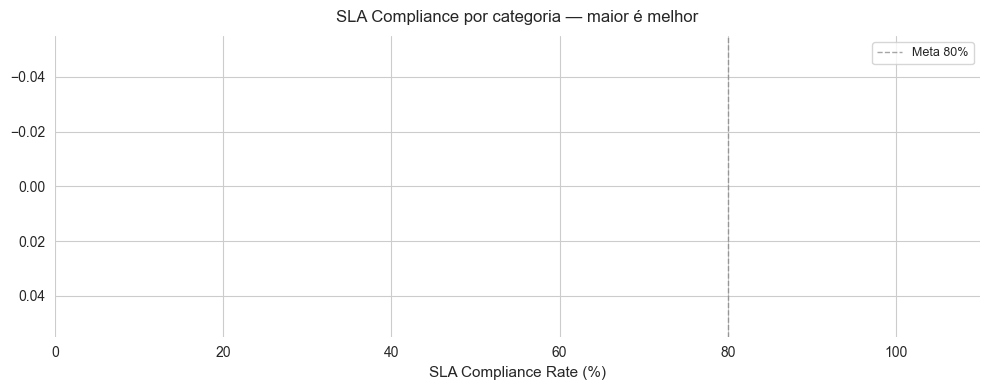

In [13]:
# Verde ≥ 80% · Laranja 60-79% · Vermelho < 60%
# Linha de referência em 80% = meta padrão de CS

plot_df = kpi.sort_values("sla_compliance", ascending=False)
colors  = ["#55A868" if v >= 80 else "#DD8452" if v >= 60 else "#C44E52"
           for v in plot_df["sla_compliance"]]

fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.55)))
bars = ax.barh(plot_df["dimension"], plot_df["sla_compliance"],
               color=colors, edgecolor="white", height=0.6)

for bar, val in zip(bars, plot_df["sla_compliance"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", ha="left", fontsize=9)

ax.axvline(x=80, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Meta 80%")
ax.legend(fontsize=9)
ax.set_xlabel("SLA Compliance Rate (%)", fontsize=11)
ax.set_title("SLA Compliance por categoria — maior é melhor", fontsize=12, pad=10)
ax.set_xlim(0, 110)
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig(CHARTS_PATH / "kpi_sla.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Gráfico C — CSAT por dimensão

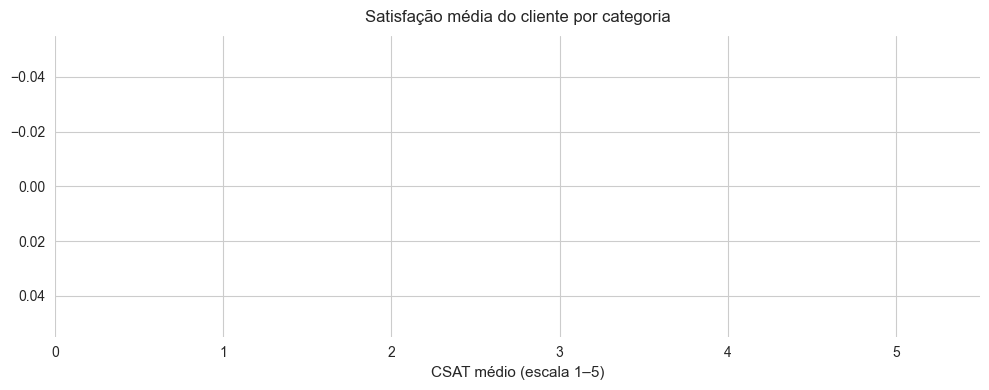

In [14]:
if CSAT_COL and "avg_csat" in kpi.columns:
    plot_df = kpi.sort_values("avg_csat", ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.55)))
    bars = ax.barh(plot_df["dimension"], plot_df["avg_csat"],
                   color="#8172B2", edgecolor="white", height=0.6)

    for bar, val in zip(bars, plot_df["avg_csat"]):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", ha="left", fontsize=9)

    ax.set_xlabel("CSAT médio (escala 1–5)", fontsize=11)
    ax.set_title("Satisfação média do cliente por categoria", fontsize=12, pad=10)
    ax.set_xlim(0, 5.5)
    ax.invert_yaxis()
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.savefig(CHARTS_PATH / "kpi_csat.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Gráfico D — Tendência de volume mensal

In [15]:
# Volume de tickets ao longo do tempo -> sinaliza sazonalidade e crescimento
# IMPORTANTE: buscamos "date" primeiro (mais especifico) antes de "purchase",
# porque "product_purchased" tambem contem a palavra "purchase" e seria
# escolhida por engano no lugar de "date_of_purchase"
date_col = next((c for c in df.columns if "date" in c), None)
if date_col is None:
    date_col = next(
        (c for c in df.columns if ("purchase" in c or "created" in c) and "product" not in c),
        None
    )

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    n_validas = df[date_col].notna().sum()
    print(f"Coluna de data: '{date_col}' | Datas validas: {n_validas:,}")

    if n_validas > 0:
        monthly = (
            df.assign(month=df[date_col].dt.to_period("M"))
              .groupby("month")
              .size()
              .reset_index(name="ticket_count")
        )
        monthly["month_str"] = monthly["month"].astype(str)

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(monthly["month_str"], monthly["ticket_count"],
                marker="o", linewidth=2, color="#4C72B0", markersize=5)
        ax.fill_between(monthly["month_str"], monthly["ticket_count"],
                        alpha=0.1, color="#4C72B0")
        ax.set_title("Tendencia mensal de tickets", fontsize=12, pad=10)
        ax.set_xlabel("Mes")
        ax.set_ylabel("Volume de tickets")

        step = max(1, len(monthly) // 10)
        ax.set_xticks(range(0, len(monthly), step))
        ax.set_xticklabels(monthly["month_str"].iloc[::step], rotation=45, ha="right")
        sns.despine()
        plt.tight_layout()
        plt.savefig(CHARTS_PATH / "kpi_volume_trend.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Grafico salvo: kpi_volume_trend.png")
    else:
        print("Nenhuma data valida encontrada.")
else:
    print("Coluna de data nao encontrada nas colunas:", df.columns.tolist())

Coluna de data não encontrada para análise de tendência.


## 8. Executive Summary — resumo executivo

In [16]:
# Esse bloco imprime o tipo de resumo que você enviaria num email de segunda-feira
overall_mttr = df["resolution_hours"].mean()
overall_sla  = df["sla_met"].mean() * 100
total_tickets = len(df)

print("=" * 55)
print("  KPI PIPELINE — RESUMO EXECUTIVO")
print("=" * 55)
print(f"  Dataset         : {total_tickets:,} tickets de suporte")
print(f"  MTTR geral      : {overall_mttr:.1f} horas")
print(f"  SLA Compliance  : {overall_sla:.1f}%")
if CSAT_COL:
    print(f"  CSAT médio      : {df[CSAT_COL].mean():.2f} / 5.0")
print()
print("  Top 3 melhores MTTR (mais rápidos):")
for _, r in kpi.nsmallest(3, "mttr_hours").iterrows():
    print(f"    {r['dimension']:<28} {r['mttr_hours']:.1f}h MTTR")
print()
print("  Bottom 3 SLA (precisam de atenção):")
for _, r in kpi.nsmallest(3, "sla_compliance").iterrows():
    print(f"    {r['dimension']:<28} {r['sla_compliance']:.1f}% SLA")
print("=" * 55)

  KPI PIPELINE — RESUMO EXECUTIVO
  Dataset         : 8,469 tickets de suporte
  MTTR geral      : nan horas
  SLA Compliance  : 0.0%
  CSAT médio      : 3.00 / 5.0

  Top 3 melhores MTTR (mais rápidos):

  Bottom 3 SLA (precisam de atenção):


## 9. Exportar kpi_processed.csv para o Power BI

In [17]:
# Esse CSV é o arquivo que o Power BI Desktop vai conectar
# Home → Get Data → Text/CSV → aponte para este arquivo

KPI_PATH.parent.mkdir(parents=True, exist_ok=True)
kpi.to_csv(KPI_PATH, index=False)

print(f"KPI exportado : {KPI_PATH}")
print(f"Shape         : {kpi.shape[0]} linhas × {kpi.shape[1]} colunas")
print()
print("Gráficos gerados em docs/screenshots/:")
for f in sorted(CHARTS_PATH.glob("*.png")):
    print(f"  {f.name}")
print()
print("=" * 55)
print("  Notebook 03 concluído.")
print("  kpi_processed.csv está pronto para o Power BI.")
print("=" * 55)

KPI exportado : c:\Users\arthu\%USERPROFILE%\Documents\GitHub\kpi-operations-pipeline\data\processed\kpi_processed.csv
Shape         : 0 linhas × 6 colunas

Gráficos gerados em docs/screenshots/:
  01_csat_distribution.png
  01_volume_by_category.png
  02_resolution_distribution.png
  kpi_csat.png
  kpi_mttr.png
  kpi_sla.png

  Notebook 03 concluído.
  kpi_processed.csv está pronto para o Power BI.
